# MAST parameter matching

Loads the mesh built by `MAST_mesh_generator.ipynb`, sets up a TokaMaker object on it, and pulls experimental shot diagnostics from FAIR-MAST as the starting point for matching experimental initial conditions and profiles into the TokaMaker+TORAX coupling.

Classify parameters as:
1. pulse dependent, piped in from MAST dataset
2. pulse independent, need to justify these through actual testing, conversing with the MAST team, and physics justification. This splits into:
    - Fixed, global constants such as geometry and transport model selection
    - Per-regime-cluster constants such as Zeff, edge Te, edge density fraction

In [ ]:
# campaigns M5-M9, 2004-2013
import numpy as np
import requests
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

BASE_URL = 'https://mastapp.site'

In [ ]:
def openShotGroup(shotId, group, level=1):
    """
    Opens a diagnostic group (amc, ayc, ane, efm, summary, etc) for a shot,
    download of pulse only happens upon a read
    """
    path = f'json/shots/{shotId}' if level == 1 else f'json/level2/shots/{shotId}'
    try:
        response = requests.get(f'{BASE_URL}/{path}')
        response.raise_for_status()
        shot = response.json()
        shotUrl = shot['url'].replace('s3:/', shot['endpoint_url'])
        return xr.open_zarr(shotUrl, group=group)
    except requests.RequestException as e:
        print(f'failed to fetch shot {shotId}: {e}')
        return None

## Load the mesh into TokaMaker

In [3]:
import os
import sys

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh

shot_id = 30421

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('MAST_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Release version:  v26.6

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.377E+01
    # of points  =   14350
    # of edges   =   42905
    # of cells   =   28556
    # of boundary points =     142
    # of boundary edges  =     142
    # of boundary cells  =     142
  Resolution statistics:
    hmin =  1.414E-04
    hrms =  3.591E-02
    hmax =  1.759E-01
  Surface grounded at vertex    3116



## Known parameters

In [4]:
efm = openShotGroup(shot_id, 'efm', level=1)
validTimes = efm['time'].values[~np.isnan(efm['plasma_current_c'].values)]
refTime = float(validTimes[0])
equilibrium = efm.sel(time=refTime, method='nearest')

print('Ip', float(equilibrium['plasma_current_c']))
print('xpoint1', float(equilibrium['xpoint1_rc']), float(equilibrium['xpoint1_zc']))
print('xpoint2', float(equilibrium['xpoint2_rc']), float(equilibrium['xpoint2_zc']))
print('qpsi', equilibrium['qpsi_c'].values)
print('ffprime', equilibrium['ffprime'].values)
print('pprime', equilibrium['pprime'].values)

ayc = openShotGroup(shot_id, 'ayc', level=1)
teValidTimeMask = ~np.isnan(ayc['te'].values).all(axis=1)
thomsonValidTimes = ayc['time'].values[teValidTimeMask]
thomsonRefTime = float(thomsonValidTimes[np.argmin(np.abs(thomsonValidTimes - refTime))])
thomson = ayc.sel(time=thomsonRefTime, method='nearest')
print('Te', thomson['te'].values)
print('ne', thomson['ne'].values)

act = openShotGroup(shot_id, 'act', level=1)
ti = act['pla_temperature'].sel(time=refTime, method='nearest')
print('Ti', ti.values)

anb = openShotGroup(shot_id, 'anb', level=1)
power = anb['tot_sum_power'].sel(time=refTime, method='nearest')

pf_active = openShotGroup(shot_id, 'pf_active', level=2)
print('P4 lower nTurns', pf_active['p4_lower_r'].size)
print('P4 upper nTurns', pf_active['p4_upper_r'].size)
print('P5 lower nTurns', pf_active['p5_lower_r'].size)
print('P5 upper nTurns', pf_active['p5_upper_r'].size)

Ip 241067.484375
xpoint1 nan nan
xpoint2 nan nan
qpsi [ 0.22396217  0.20934992  0.21078618  0.21181622  0.21258578  0.2131614
  0.21360627  0.21399735  0.21437304  0.21476336  0.21518701  0.21567021
  0.2162159   0.21684787  0.2175769   0.21841988  0.21939977  0.2205338
  0.22183646  0.22332895  0.22503777  0.22699185  0.2292227   0.23176517
  0.23464724  0.23789309  0.24151324  0.24553739  0.25000462  0.25496662
  0.2604845   0.2666178   0.27344963  0.28105918  0.28953356  0.29898712
  0.30954695  0.3213594   0.33461028  0.34950766  0.36623842  0.38502285
  0.40612948  0.42990422  0.4567548   0.4871794   0.521772    0.5612588
  0.60657936  0.65891683  0.71982384  0.7912213   0.8756255   0.97638446
  1.0981737   1.2474167   1.4334029   1.6698154   1.9781989   2.3930995
  2.973691    3.8263733   5.1543207   7.473608   11.411743  ]
ffprime [ 1.22449312e+01  1.18068008e+01  1.13765059e+01  1.09540462e+01
  1.05394211e+01  1.01326313e+01  9.73367596e+00  9.34255600e+00
  8.95927143e+00  8.

## Derived parameters

In [ ]:
def buildGeqdsk(eq):
    """
    Map efm equibrium to read_eqdsk() keys
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    lcfsR, lcfsZ = eq['lcfs_r'].values, eq['lcfs_z'].values
    lcfsValid = ~np.isnan(lcfsR) & ~np.isnan(lcfsZ)
    return {
        'nr': len(gridR),
        'nz': len(gridZ),
        'rdim': float(gridR.max() - gridR.min()),
        'zdim': float(gridZ.max() - gridZ.min()),
        'rleft': float(gridR.min()),
        'zmid': float((gridZ.max() + gridZ.min()) / 2.0),
        'rcentr': float(eq['rvtor']),
        'bcentr': float(eq['bvac_val']),
        'raxis': float(eq['magnetic_axis_r']),
        'zaxis': float(eq['magnetic_axis_z']),
        'psimag': float(eq['psi_axis']),
        'psibry': float(eq['psi_boundary']),
        'ip': float(eq['plasma_current_c']),
        'fpol': eq['fpsi_c'].values,
        'pres': eq['ppsi_c'].values,
        'ffprim': eq['ffprime'].values,
        'pprime': eq['pprime'].values,
        'psirz': eq['psirz'].values[:, validCols],
        'qpsi': eq['qpsi_c'].values,
        'rzout': np.column_stack([lcfsR[lcfsValid], lcfsZ[lcfsValid]]),
        'rzlim': np.column_stack([eq['limiterr'].values, eq['limiterz'].values]),
    }

def psiNormAtMidplane(rQuery, eq):
    """
    Maps midplane R to normalized poloidal flux using the cleaned psirz grid
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    psirzClean = eq['psirz'].values[:, validCols]
    interp = RegularGridInterpolator((gridZ, gridR), psirzClean, bounds_error=False, fill_value=None)
    # Thomson chords at Z=0
    psi = interp(np.column_stack([np.zeros_like(rQuery), rQuery]))
    return (psi - float(eq['psi_axis'])) / (float(eq['psi_boundary']) - float(eq['psi_axis']))

def rhoTorNormFromPsiNorm(psiNormQuery, eq):
    """
    rho_tor_norm = sqrt(enclosed toroidal flux / total toroidal flux)
    """
    psiNorm65 = eq['psi_norm'].values
    q = eq['qpsi_c'].values
    torFlux = np.concatenate([[0.0], np.cumsum(0.5 * (q[1:] + q[:-1]) * np.diff(psiNorm65))])
    torFluxNorm = torFlux / torFlux[-1]
    return np.interp(np.clip(psiNormQuery, 0, 1), psiNorm65, torFluxNorm) ** 0.5

def mapThomsonToRho(shotId, refTime, eq):
    thomson = openShotGroup(shotId, 'ayc', level=1).sel(time=refTime, method='nearest')
    r, te, ne = thomson['radius'].values, thomson['te'].values, thomson['ne'].values
    valid = ~np.isnan(r) & ~np.isnan(te) & ~np.isnan(ne)
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq)
    return rho, te[valid], ne[valid]

def gasPuffRate(shotId, coarseDt=0.01):
    """
    Need a particle rate for set_fueling. gas_injection only gives a cumulative
    injected count, resample onto a coarser time grid before differentiating.
    """
    ds = openShotGroup(shotId, 'gas_injection', level=2)
    t, total = ds['time'].values, ds['total_injected'].values
    tCoarse = np.arange(t.min(), t.max(), coarseDt)
    totalCoarse = np.interp(tCoarse, t, total)
    rateCoarse = np.clip(np.gradient(totalCoarse, tCoarse), 0, None)
    return dict(zip(tCoarse.tolist(), rateCoarse.tolist()))

In [6]:
geqdsk = buildGeqdsk(equilibrium)

# ppsi_c/pprime come from efm sign-flipped as a matched pair
geqdsk['pres'] = -geqdsk['pres']
geqdsk['pprime'] = -geqdsk['pprime']

F0 = float(equilibrium['rvtor'] * equilibrium['bvac_val'])
mygs.setup(order=2, F0=F0)

for name in ['p2_inner_lower', 'p2_inner_upper', 'p2_outer_lower', 'p2_outer_upper', 'p3_lower', 'p3_upper', 'p6_lower', 'p6_upper', 'sol']:
    print(name, 'nTurns', pf_active[f'{name}_r'].size)

# Initial kinetic profiles, Te/ne from Thomson 
rhoInit, teInit, neInit = mapThomsonToRho(shot_id, thomsonRefTime, equilibrium)

gasPuffSTotal = gasPuffRate(shot_id)

print('F0', F0)
print('psirz shape', geqdsk['psirz'].shape, 'nan count', np.isnan(geqdsk['psirz']).sum())
print('rzout', geqdsk['rzout'])
print('pres', geqdsk['pres'])
print('pprime', geqdsk['pprime'])
print('rho_tor_norm', rhoInit)
print('Te on rho grid', teInit)
print('ne on rho grid', neInit)
print('gas puff rate breakpoints', len(gasPuffSTotal))


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.1730000000000000E-003
p2_inner_lower nTurns 12
p2_inner_upper nTurns 12
p2_outer_lower nTurns 8
p2_outer_upper nTurns 8
p3_lower nTurns 8
p3_upper nTurns 8
p6_lower nTurns 4
p6_upper nTurns 4
sol nTurns 656
F0 -0.40025240182876587
psirz shape (65, 65) nan count 0
rzout [[ 0.19634606  0.        ]
 [ 0.20208846  0.0625    ]
 [ 0.2115625   0.12137273]
 [ 0.21210012  0.125     ]
 [ 0.22642982  0.1875    ]
 [ 0.241875    0.23329233]
 [ 0.24800058  0.25      ]
 [ 0.2721875   0.30177993]
 [ 0.27814853  0.3125    ]
 [ 0.3025      0.35108516]
 [ 0.3221909   0.375     ]
 [ 0.3328125   0.3871413 ]
 [ 0.363125    0.41506276]
 [ 0.3934375   0.43484396]
 [ 0.3986797   0.4375    ]
 [ 0.42375     0.4504328 ]
 [ 0.4540625   0.46159238]
 [ 0.484375    0.46895042]
 [ 0.5146875   0.4731632 ]
 [ 0.545       0.47465983]
 [ 0.5753125   0.47371542]
 [ 0.605625    0.47048512]
 [ 0.

P6 is wired in anti-series based on:
- *High performance plasma vertical position control system for upgraded MAST* 
- *Validation of the static forward Grad-Shafranov equilibrium solvers in FreeGSNKE and Fiesta using EFIT++ reconstructions from MAST-U* 

In [7]:
# TokaMaker_TORAX requires cocos=2 
signIp = np.sign(geqdsk['ip'])
signB0 = np.sign(geqdsk['bcentr'])
signPsi = np.sign(geqdsk['psibry'] - geqdsk['psimag'])

print('coil_sets', mygs.coil_sets)
print('sign Ip', signIp)
print('sign B0', signB0)
print('sign psi_bry - psi_mag', signPsi)

coil_sets {'P2_INNER_LOWER': {'id': 0, 'net_turns': 12.0, 'sub_coils': [{'reg_id': 5, 'coil_id': 0, 'nturns': 12, 'coil_set': 'P2_INNER_LOWER', 'allow_xpoints': False, 'name': 'P2_INNER_LOWER'}]}, 'P2_INNER_UPPER': {'id': 1, 'net_turns': 12.0, 'sub_coils': [{'reg_id': 6, 'coil_id': 1, 'nturns': 12, 'coil_set': 'P2_INNER_UPPER', 'allow_xpoints': False, 'name': 'P2_INNER_UPPER'}]}, 'P2_OUTER_LOWER': {'id': 2, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 7, 'coil_id': 2, 'nturns': 8, 'coil_set': 'P2_OUTER_LOWER', 'allow_xpoints': False, 'name': 'P2_OUTER_LOWER'}]}, 'P2_OUTER_UPPER': {'id': 3, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 8, 'coil_id': 3, 'nturns': 8, 'coil_set': 'P2_OUTER_UPPER', 'allow_xpoints': False, 'name': 'P2_OUTER_UPPER'}]}, 'P3_LOWER': {'id': 4, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 9, 'coil_id': 4, 'nturns': 8, 'coil_set': 'P3_LOWER', 'allow_xpoints': False, 'name': 'P3_LOWER'}]}, 'P3_UPPER': {'id': 5, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 10, 'coil_id': 5, 

Starting non-linear GS solver
     1 -1.5380E+01  2.1723E+01  3.5872E+00  8.2600E-01 -8.5258E-03 -0.0000E+00
     2 -1.1257E+00  3.6110E+00  1.0720E+00  8.1776E-01 -8.6824E-03 -0.0000E+00
     3 -4.9183E+00  6.9615E+00  7.3453E-01  8.2870E-01 -8.5146E-03 -0.0000E+00
     4 -5.6967E+00  7.9117E+00  1.4769E-01  8.3580E-01 -8.2198E-03 -0.0000E+00
     5 -5.3870E+00  7.5669E+00  5.7480E-02  8.3790E-01 -8.3002E-03 -0.0000E+00
     6 -5.4718E+00  7.6823E+00  4.9487E-02  8.3903E-01 -8.2977E-03 -0.0000E+00
     7 -5.4229E+00  7.6314E+00  3.1010E-03  8.3938E-01 -8.2946E-03 -0.0000E+00
     8 -5.4322E+00  7.6456E+00  1.0923E-02  8.3955E-01 -8.2922E-03 -0.0000E+00
     9 -5.4247E+00  7.6383E+00  2.2064E-03  8.3960E-01 -8.2905E-03 -0.0000E+00
    10 -5.4255E+00  7.6399E+00  2.2653E-03  8.3962E-01 -8.2895E-03 -0.0000E+00
    11 -5.4243E+00  7.6388E+00  6.2628E-04  8.3962E-01 -8.2888E-03 -0.0000E+00
    12 -5.4244E+00  7.6390E+00  4.3450E-04  8.3962E-01 -8.2884E-03 -0.0000E+00
    13 -5.4242E+00  7.

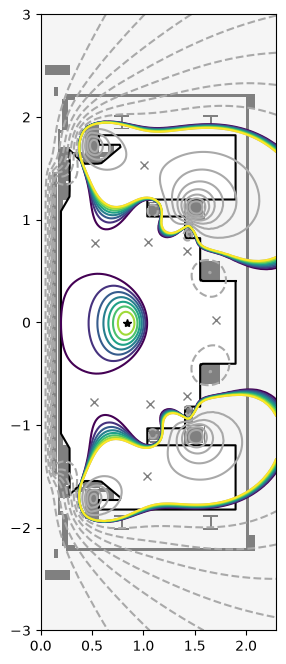

In [8]:
# regularization pulls coil currents toward zero so the solve is plausible
regTerms = [mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-4) for name in mygs.coil_sets]
mygs.set_coil_reg(reg_terms=regTerms)

paxTarget = abs(geqdsk['pres'][0])
mygs.set_targets(Ip=geqdsk['ip'], pax=paxTarget)
mygs.set_isoflux_constraints(geqdsk['rzout'])

rzout = geqdsk['rzout']
r0 = float(equilibrium['magnetic_axis_r'])
z0 = float(equilibrium['magnetic_axis_z'])
a = float((rzout[:, 0].max() - rzout[:, 0].min()) / 2.0)
kappa = float((rzout[:, 1].max() - rzout[:, 1].min()) / (2.0 * a))
mygs.init_psi(r0=r0, z0=z0, a=a, kappa=kappa, delta=0.0)

mygs.settings.maxits = 100
equil, nIts = mygs.solve(return_its=True)
print('converged in', nIts, 'iterations')

stats = mygs.get_stats()
for k, v in stats.items():
    print(f'{k} = {v}')

fig, ax = plt.subplots(figsize=(5, 8))
mygs.plot_machine(fig, ax)
mygs.plot_psi(fig, ax)